In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import imdb

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/opt/anaconda3/envs/nlp-ml-m3/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Keep top 10,000 most frequent words to limit vocab size
num_words = 10000

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=num_words)

print("Train samples:", len(X_train_raw))
print("Test samples:", len(X_test_raw))
print("Example encoded review:", X_train_raw[0][:20], "...")
print("Label (0=neg, 1=pos):", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train samples: 25000
Test samples: 25000
Example encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Label (0=neg, 1=pos): 1


In [3]:
word_index = imdb.get_word_index()
reverse_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    # In Keras IMDB, indices 0,1,2 are reserved; real words start at index 3
    return " ".join([reverse_index.get(i - 3, "?") for i in encoded_review])

texts_train = [decode_review(review) for review in X_train_raw]
texts_test  = [decode_review(review) for review in X_test_raw]

print(texts_train[0][:500])


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever


In [4]:
vectorizer = TfidfVectorizer(
    max_features=20000,      # cap vocab size
    stop_words="english",    # remove common English stopwords
)

X_train = vectorizer.fit_transform(texts_train)
X_test  = vectorizer.transform(texts_test)

X_train.shape, X_test.shape


((25000, 9477), (25000, 9477))

In [5]:
clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.8812


/opt/anaconda3/envs/nlp-ml-m3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [6]:
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.8824    0.8797    0.8810     12500
           1     0.8800    0.8827    0.8814     12500

    accuracy                         0.8812     25000
   macro avg     0.8812    0.8812    0.8812     25000
weighted avg     0.8812    0.8812    0.8812     25000



In [7]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred,
    average="binary",  # positive class = 1
    pos_label=1
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)


Accuracy : 0.8812
Precision: 0.8800446642207689
Recall   : 0.88272
F1-score : 0.8813803019410497


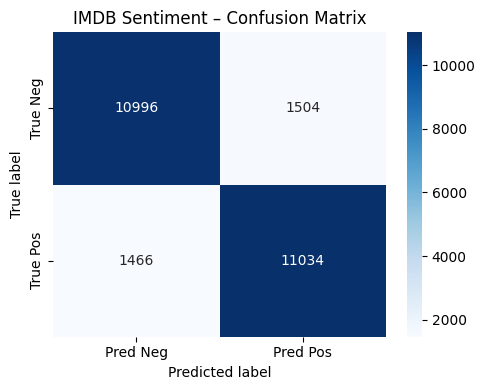

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["True Neg", "True Pos"])
plt.title("IMDB Sentiment – Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
